# Pytorch

**GOAL:** - develop multi-class image classifier utilizing pytorch and AI.

Steps:

1. Break pdf files into component sheets, convert those sheets into images,  
load the images as tensors $ C \times H \times W $ (channels, height, width) layout

2. Labeling - Data needs broken up into if it's a "Framing Plan", "Site  
Plan", "Cross-Section", etc.

3. Preprocessing - Minimizing the variation in the images for the model as  
much as possible is critical to the labeling's success



# Breaking up pdfs

(PDFs were downloaded from TIMs in the Bridge Queries Notebook)

In [1]:
import os
import PyPDF2

In [3]:
def split_pdfs(input_folder, output_folder):
    """
    Splits all PDF files in a given folder into single-page PDF files.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(".pdf"):
            pdf_path = os.path.join(input_folder, filename)
            try:
                with open(pdf_path, 'rb') as file:
                    reader = PyPDF2.PdfReader(file)
                    num_pages = len(reader.pages)

                    if num_pages > 1:
                        print(f"Splitting {filename} into {num_pages} pages...")
                        for i in range(num_pages):
                            writer = PyPDF2.PdfWriter()
                            writer.add_page(reader.pages[i])
                            
                            base_name = os.path.splitext(filename)[0]
                            output_filename = f"{base_name}-page{i+1:02}.pdf"
                            output_path = os.path.join(output_folder, output_filename)
                            
                            with open(output_path, 'wb') as output_file:
                                writer.write(output_file)
                        print(f"Successfully split {filename}")
                    else:
                        print(f"Skipping {filename}: it only has one page.")

            except Exception as e:
                print(f"An error occurred with {filename}: {e}")

In [4]:
if __name__ == "__main__":
    input_directory = r'C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge'
    output_directory = os.path.join(input_directory, 'unlabeled pages')
    split_pdfs(input_directory, output_directory)
    print("PDF splitting process completed.")

Splitting B - D01-109907_PlanSet_AsAdvertised.pdf into 22 pages...
Successfully split B - D01-109907_PlanSet_AsAdvertised.pdf
Splitting B - D02-3763-LUC-00475-13.89-1993-00.pdf into 91 pages...
Successfully split B - D02-3763-LUC-00475-13.89-1993-00.pdf
Splitting B - D06-4666-FRA-00670-4.06-2001-00.pdf into 333 pages...
Successfully split B - D06-4666-FRA-00670-4.06-2001-00.pdf
Splitting B - D06-4668-FRA-00315-1.35-1998-00.pdf into 117 pages...
Successfully split B - D06-4668-FRA-00315-1.35-1998-00.pdf
Splitting B - D06-4677-FRA-00670-1.05-1998-00.pdf into 104 pages...
Successfully split B - D06-4677-FRA-00670-1.05-1998-00.pdf
Splitting B - D12-13486-LAK-00002-7.61-2008-00.pdf into 392 pages...
Successfully split B - D12-13486-LAK-00002-7.61-2008-00.pdf
Splitting B - FRA-105498-Plan.pdf into 82 pages...
Successfully split B - FRA-105498-Plan.pdf
PDF splitting process completed.


# Convert the sheets to images to be processed by the AI

In [7]:
import os
from pdf2image import convert_from_path

In [8]:
def convert_and_replace_pdfs(folder_path):
    """
    Converts all single-page PDF files in a given folder into JPEG images
    and then deletes the original PDF file.

    Args:
        folder_path (str): The path to the folder containing PDF files.
    """
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    # You can adjust the quality value (0-100)
    # Lower quality = faster conversion, smaller file size, more compression artifacts
    # Higher quality = slower conversion, larger file size, less compression artifacts
    jpeg_quality = 85

    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            base_name = os.path.splitext(filename)[0]

            print(f"Processing '{filename}'...")
            try:
                # Convert the single-page PDF to a JPEG image
                images = convert_from_path(pdf_path,
                                           poppler_path=r'C:\Users\dparks1\OneDrive - State of Ohio\Apps\Poppler\Library\bin')
                
                # Assuming each PDF is only one page
                if images:
                    jpg_path = os.path.join(folder_path, base_name + ".jpg")
                    images[0].save(jpg_path, "JPEG", quality=jpeg_quality)
                    print(f"Converted '{filename}' to '{os.path.basename(jpg_path)}' with quality {jpeg_quality}")
                    
                    # Delete the original PDF file
                    os.remove(pdf_path)
                    print(f"Deleted original PDF: '{filename}'")
                else:
                    print(f"Warning: No images found in '{filename}'. Skipping deletion.")

            except Exception as e:
                print(f"An error occurred while converting '{filename}': {e}")
                print("Please ensure that Poppler is installed and the 'poppler_path' is correct.")
    
    print("\nConversion process completed.")

In [10]:
if __name__ == "__main__":
    # Define your input directory here
    input_directory = r'C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages'
    
    # This script will now operate directly on the 'unlabeled pages' folder
    convert_and_replace_pdfs(input_directory)

Processing 'B - D06-4668-FRA-00315-1.35-1998-00-page59.pdf'...
Converted 'B - D06-4668-FRA-00315-1.35-1998-00-page59.pdf' to 'B - D06-4668-FRA-00315-1.35-1998-00-page59.jpg' with quality 85
Deleted original PDF: 'B - D06-4668-FRA-00315-1.35-1998-00-page59.pdf'
Processing 'B - D06-4668-FRA-00315-1.35-1998-00-page60.pdf'...


KeyboardInterrupt: 

# Labeling

Briefly thought of rolling my own for this, then I found this instead,

[label studio](https://labelstud.io/)

**Getting a list of which files are labeled**

In [5]:
import json
import urllib.parse

json_file_path = r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\labels\test_data.json"

In [7]:
file_paths = []

with open(json_file_path, 'r') as f:
    data = json.load(f)

# List to store the final, clean paths
full_file_paths = []

# Loop through each task
for task in data:
    if 'data' in task and 'image' in task['data']:
        # Get the URL-encoded path from Label Studio
        encoded_url = task['data']['image']
        
        # 1. Split the URL to get only the part with the file path
        # It's the part after '?d='
        encoded_path_part = encoded_url.split('?d=')[1]
        
        # 2. Decode the path (e.g., convert %5C to \ and %20 to a space)
        decoded_path = urllib.parse.unquote(encoded_path_part)
        
        # 3. Prepend the drive letter to make it a full Windows path
        # We need to use "C:\\" so Python treats the backslash correctly
        full_path = "C:\\" + decoded_path
        
        full_file_paths.append(full_path)

# Print the final list of clean, decoded paths
print(f"Found and decoded {len(full_file_paths)} file paths.")
for path in full_file_paths:
    print(path)

Found and decoded 23 file paths.
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page01.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page02.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page03.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page04.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page05.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page06.jpg
C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D01-109907_PlanSet_AsAdvertised-page07.jpg
C

# Proof of Concept Demo

In [1]:
import json
import os
import torch
from PIL import Image
from urllib.parse import urlparse, unquote

In [2]:
def parse_label_studio_json(json_path):
    """
    Parses a Label Studio JSON file and extracts bounding box and label data.
    """
    data = {}
    try:
        with open(json_path, 'r') as f:
            tasks = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {json_path} was not found.")
        return data

    # Map your string labels to integer IDs. Make sure to include all your labels.
    label_map = {
        "Agency": 1,
        "PID": 2,
        "Designer": 3,
        "Reviewer": 4,
        "Sheet Number": 5,
        "Total": 6,
        "Designer Stamp": 7,
        "Special Provisions": 8,
        "Supplemental Specifications": 9,
        "Standard Construction Drawings": 10,
        "Design Data": 11,
        "Location Map": 12,
        "Print Details": 13,
        "Sheet Index": 14,
        "FAN": 15,
        "RR Involvement": 16,
        "Specs": 17,
        "Sheet Title": 18,
        "Title Block": 19,
        "General Notes": 20,
        "Note": 21,
        "Table": 22,
        "Sheet": 23
    }
    
    for task in tasks:
        if 'data' not in task or 'image' not in task['data']:
            continue

        image_url = task['data']['image']
        parsed_url = urlparse(image_url)
        
        # The query parameter contains the path
        if not parsed_url.query:
            print(f"Warning: No query parameter found in URL for {image_url}. Skipping.")
            continue
            
        # Get the 'd' parameter from the query string
        query_params = dict(param.split('=') for param in parsed_url.query.split('&'))
        
        if 'd' in query_params:
            # 1. Decode the URL-encoded path fragment
            path_fragment = unquote(query_params['d'])
            
            # 2. Prepend the drive letter to make it a full path.
            # This is necessary because Label Studio exports relative paths on Windows.
            image_path = "C:\\" + path_fragment
        else:
            print(f"Warning: No 'd' parameter found in URL for {image_url}. Skipping.")
            continue
        
        # 3. Normalize the path to handle slashes correctly
        image_path = os.path.normpath(image_path)
        
        # Check if the generated path exists
        if not os.path.exists(image_path):
            print(f"Warning: Image not found at {image_path}. Skipping.")
            continue
        
        if not task['annotations']:
            continue
            
        annotation = task['annotations'][0]
        
        boxes = []
        labels = []
        
        # Load the image and get dimensions to scale bounding boxes
        with Image.open(image_path) as img:
            img_w, img_h = img.size

        for result in annotation['result']:
            if 'rectanglelabels' in result['value']:
                box_label = result['value']['rectanglelabels'][0]
                if box_label in label_map:
                    x_norm = result['value']['x'] / 100.0
                    y_norm = result['value']['y'] / 100.0
                    width_norm = result['value']['width'] / 100.0
                    height_norm = result['value']['height'] / 100.0
                    
                    x_min = x_norm * img_w
                    y_min = y_norm * img_h
                    x_max = (x_norm + width_norm) * img_w
                    y_max = (y_norm + height_norm) * img_h
                    
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(label_map[box_label])

        if boxes:
            data[image_path] = {
                'boxes': torch.tensor(boxes, dtype=torch.float32),
                'labels': torch.tensor(labels, dtype=torch.int64)
            }
            
    return data

In [3]:
# Example usage
json_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\labels\test_data.json"

parsed_data = parse_label_studio_json(json_file)

## Create Custom Pytorch

In [4]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

In [5]:
class LabelStudioDataset(Dataset):
    def __init__(self, data_dict):
        self.data_dict = data_dict
        self.image_paths = list(data_dict.keys())
        
        # Define a simple transform to convert PIL image to tensor
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        target = self.data_dict[image_path]
        
        # Apply the transform to convert the image to a tensor
        image = self.transform(image)
        
        return image, target

## Create the PyTorch Model

In [6]:
# Example of creating the dataset
# You'll need to define your transforms, such as torchvision.transforms.Compose
dataset = LabelStudioDataset(parsed_data)

In [7]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

def get_object_detection_model(num_classes):
    # Load a pre-trained model on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained box predictor with a new one for your classes
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    
    return model

# The number of classes is the number of your labels + 1 (for the background class)
num_classes = len(set(label for data in parsed_data.values() for label in data['labels'].tolist())) + 1
model = get_object_detection_model(num_classes)

In [8]:
import torch.optim as optim
from torch.utils.data import DataLoader

# Create the DataLoader with the collate function
def collate_fn(batch):
    return tuple(zip(*batch))

data_loader = DataLoader(
    dataset,
    batch_size=2,  # Adjust as needed
    shuffle=True,
    collate_fn=collate_fn
)

## Training

In [9]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
num_epochs = 10

# Put model in training mode
model.train()

for epoch in range(num_epochs):
    for images, targets in data_loader:
        # The images are now already tensors, so you can move them to the device directly
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {losses.item()}")

print("Training complete! 🎉")

Epoch 1/10, Loss: 1.1038010120391846
Epoch 2/10, Loss: 1.2341543436050415
Epoch 3/10, Loss: 1.1775673627853394
Epoch 4/10, Loss: 1.502673864364624
Epoch 5/10, Loss: 1.1822870969772339
Epoch 6/10, Loss: 2.046215772628784
Epoch 7/10, Loss: 1.1684460639953613
Epoch 8/10, Loss: 0.7664647102355957
Epoch 9/10, Loss: 0.9796502590179443
Epoch 10/10, Loss: 0.4195411503314972
Training complete! 🎉


## Check Model's Accuracy

In [10]:
# Put the model in evaluation mode
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [11]:
from PIL import Image
from torchvision import transforms

# Define the same transformation used for training
transform = transforms.ToTensor()

# Load and transform a new image
image_path = r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\Bridge\unlabeled pages\B - D02-3763-LUC-00475-13.89-1993-00-page10.jpg"
image_pil = Image.open(image_path).convert("RGB")
image_tensor = transform(image_pil)

In [12]:
# Move the tensor to the same device as the model (e.g., GPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
image_tensor = image_tensor.to(device)

# The model expects a list of tensors as input
with torch.no_grad():
    predictions = model([image_tensor])

# The output is a dictionary for a single image
predicted_boxes = predictions[0]['boxes']
predicted_labels = predictions[0]['labels']
predicted_scores = predictions[0]['scores']

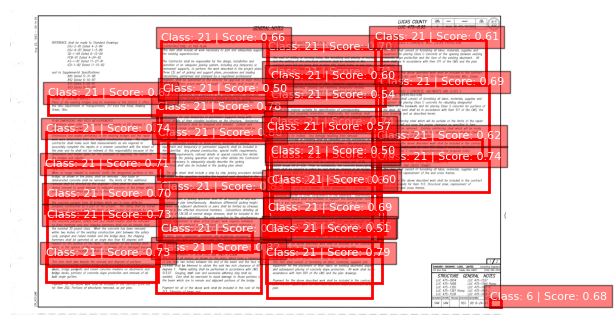

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Convert the image to a format suitable for plotting
image_np = image_pil.convert("RGB")

# Set a score threshold to filter out low-confidence predictions
score_threshold = 0.5

fig, ax = plt.subplots(1)
ax.imshow(image_np)

# Iterate through the predictions
for box, label, score in zip(predicted_boxes, predicted_labels, predicted_scores):
    if score > score_threshold:
        # Get coordinates
        x_min, y_min, x_max, y_max = box.cpu().numpy()
        
        # Create a Rectangle patch
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        
        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the label
        plt.text(x_min, y_min - 5, f'Class: {label.item()} | Score: {score.item():.2f}',
                 bbox=dict(facecolor='red', alpha=0.5), fontsize=8, color='white')

plt.axis('off')
plt.show()

# Need to Get to a Self-Reinforcing WorkFlow

More data should result in better accuracy, generally easier to fix  
predictions than to create annotations by hand.

In [14]:
import os
from pdf2image import convert_from_path
from concurrent.futures import ProcessPoolExecutor
from functools import partial
import time

In [2]:
def process_single_pdf(pdf_path, folder_path, poppler_path, jpeg_quality):
    """
    Processes a single PDF file: converts it to JPEG and deletes the original.
    This function is designed to be run in a separate process.
    """
    filename = os.path.basename(pdf_path)
    base_name = os.path.splitext(filename)[0]
    
    try:
        print(f"Processing '{filename}'...")
        
        # Convert the single-page PDF to a JPEG image
        images = convert_from_path(pdf_path, poppler_path=poppler_path)
        
        # Assuming each PDF is only one page
        if images:
            jpg_path = os.path.join(folder_path, base_name + ".jpg")
            images[0].save(jpg_path, "JPEG", quality=jpeg_quality)
            
            # Delete the original PDF file after successful conversion
            os.remove(pdf_path)
            
            return f"Successfully converted and deleted '{filename}'"
        else:
            return f"Warning: No images found in '{filename}'. PDF not deleted."

    except Exception as e:
        return f"Error processing '{filename}': {e}"

In [5]:
def convert_pdfs_in_parallel(folder_path, poppler_path):
    """
    Converts all single-page PDF files in a folder to JPEG images in parallel
    and then deletes the original PDF files.
    """
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    # --- Configuration ---
    jpeg_quality = 85
    
    # Get a list of all PDF files to process *before* starting
    pdf_files = [
        os.path.join(folder_path, f) 
        for f in os.listdir(folder_path) if f.lower().endswith(".pdf")
    ]

    if not pdf_files:
        print("No PDF files found to convert.")
        return

    print(f"Found {len(pdf_files)} PDF files to convert.")

    # Use a ProcessPoolExecutor to manage a pool of worker processes
    # The 'with' statement ensures the pool is properly shut down
    with ProcessPoolExecutor(max_workers=4) as executor:
        # We use functools.partial to "pre-fill" the arguments that are the
        # same for every function call (folder_path, poppler_path, etc.)
        process_func = partial(
            process_single_pdf,
            folder_path=folder_path,
            poppler_path=poppler_path,
            jpeg_quality=jpeg_quality
        )
        
        # executor.map applies the function to each item in the pdf_files list.
        # It distributes the work among the available CPU cores.
        results = executor.map(process_func, pdf_files)

        # Print results as they complete
        for result in results:
            print(result)

    print("\nConversion process completed.")

In [6]:
# --- How to use it ---
if __name__ == "__main__":
    start_time = time.time()
    
    # Configure your paths here
    target_folder = r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\unlabeled pages"
    poppler_installation_path = r'C:\Users\dparks1\OneDrive - State of Ohio\Apps\Poppler\Library\bin'
    
    convert_pdfs_in_parallel(target_folder, poppler_installation_path)
    
    end_time = time.time()
    print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Found 35570 PDF files to convert.


BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore

In [3]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from pdf2image import convert_from_path

In [4]:
def convert_pdf_to_jpeg(pdf_path, poppler_path, jpeg_quality=85):
    base_name = os.path.splitext(os.path.basename(pdf_path))[0]
    folder_path = os.path.dirname(pdf_path)

    try:
        images = convert_from_path(pdf_path, poppler_path=poppler_path)
        if images:
            jpg_path = os.path.join(folder_path, base_name + ".jpg")
            images[0].save(jpg_path, "JPEG", quality=jpeg_quality)
            os.remove(pdf_path)
            return f"✅ Converted and deleted: {os.path.basename(pdf_path)}"
        else:
            return f"⚠️ No images found in: {os.path.basename(pdf_path)}"
    except Exception as e:
        return f"❌ Error with {os.path.basename(pdf_path)}: {e}"

In [5]:
def convert_and_replace_pdfs(folder_path):
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    poppler_path = r'C:\Users\dparks1\OneDrive - State of Ohio\Apps\Poppler\Library\bin'
    jpeg_quality = 85

    pdf_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".pdf")]

    if not pdf_files:
        print("No PDF files found.")
        return

    print(f"Found {len(pdf_files)} PDF files. Starting conversion...\n")

    with ThreadPoolExecutor(max_workers=4) as executor:  # Adjust number of workers as needed
        futures = [executor.submit(convert_pdf_to_jpeg, pdf, poppler_path, jpeg_quality) for pdf in pdf_files]

        for future in as_completed(futures):
            print(future.result())

    print("\n✅ All conversions completed.")

In [ ]:
# convert_and_replace_pdfs(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\unlabeled pages")

Found 35663 PDF files. Starting conversion...

✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page23.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page229.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page227.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page228.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page230.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page231.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page233.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page232.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page235.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page234.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page237.pdf
✅ Converted and deleted: D02-9443-SAN-00053-11.78-2004-00-page236.pdf
